# Data-Centric AI (Model 1)

### Author: Nischal Pradhan

| **Task**                  | **Sub Task**                   | **Comments (Status/Finding)**   | **Assigned To**               |
|---------------------------|--------------------------------|---------------------------------|-------------------------------|
| Data-Centric AI (Model 1) | Interpretability Implemented   | LIME/SHAP Implemented           | Nischal Pradhan               |
|                           | 1st Round of Tuning            | Issue Faced / Fix Applied       | Nischal Pradhan               |
|                           | 2nd Round of Tuning            | Issue Faced / Fix Applied       | Nischal Pradhan               |


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

In [ ]:
base_dir = './../prepocessed_v2'
img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    f"{base_dir}/train", target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    f"{base_dir}/val", target_size=img_size, batch_size=batch_size, class_mode='categorical'
)

Found 72017 images belonging to 5 classes.
Found 8964 images belonging to 5 classes.


In [ ]:
input_shape = (224, 224, 3)
vgg = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)

for layer in vgg.layers[:-4]:
    layer.trainable = False

x = Flatten()(vgg.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

model = Model(inputs=vgg.input, outputs=output)
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
def tune_model(model, train_gen, val_gen, round_label="Tuning", fast_run=False):
    print(f"\n{round_label} - Model 1 Tuning")

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

    steps_train = 50 if fast_run else None
    steps_val = 10 if fast_run else None
    epochs = 5 if fast_run else 15

    start = time.time()
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        epochs=epochs,
        callbacks=[early_stop, reduce_lr],
        verbose=2
    )
    end = time.time()
    print(f"\nTraining Time: {(end-start)/60:.2f} mins")

    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title('Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Val')
    plt.title('Accuracy')
    plt.legend()
    plt.show()

    val_preds = model.predict(val_gen, verbose=0)
    y_true = val_gen.classes
    y_pred = np.argmax(val_preds, axis=1)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {round_label}')
    plt.show()

    try:
        auc = roc_auc_score(y_true, val_preds, multi_class='ovr')
        print(f"AUC: {auc:.4f}")
    except:
        print("AUC computation failed.")

    print("\nF1 Scores:")
    print("F1 Macro:", f1_score(y_true, y_pred, average='macro'))
    print("F1 Micro:", f1_score(y_true, y_pred, average='micro'))
    print("F1 Weighted:", f1_score(y_true, y_pred, average='weighted'))

    print("\nPrecision Scores:")
    print("Precision Macro:", precision_score(y_true, y_pred, average='macro'))
    print("Precision Micro:", precision_score(y_true, y_pred, average='micro'))
    print("Precision Weighted:", precision_score(y_true, y_pred, average='weighted'))

    print("\nRecall Scores:")
    print("Recall Macro:", recall_score(y_true, y_pred, average='macro'))
    print("Recall Micro:", recall_score(y_true, y_pred, average='micro'))
    print("Recall Weighted:", recall_score(y_true, y_pred, average='weighted'))

    return model

#### Tuning



Iteration 1 - Model 1 Tuning
Epoch 1/10
70/70 - 217s - 3s/step - accuracy: 0.9987 - loss: 0.0058 - val_accuracy: 0.9463 - val_loss: 0.2498 - learning_rate: 2.5000e-05
Epoch 2/10
70/70 - 215s - 3s/step - accuracy: 0.9964 - loss: 0.0104 - val_accuracy: 0.9388 - val_loss: 0.2505 - learning_rate: 2.5000e-05
Epoch 3/10
70/70 - 7719s - 110s/step - accuracy: 0.9955 - loss: 0.0147 - val_accuracy: 0.9388 - val_loss: 0.2710 - learning_rate: 2.5000e-05
Epoch 4/10
70/70 - 230s - 3s/step - accuracy: 0.9982 - loss: 0.0072 - val_accuracy: 0.9381 - val_loss: 0.3205 - learning_rate: 2.5000e-05
Epoch 5/10
70/70 - 233s - 3s/step - accuracy: 0.9969 - loss: 0.0099 - val_accuracy: 0.9325 - val_loss: 0.2981 - learning_rate: 1.2500e-05
Epoch 6/10
70/70 - 197s - 3s/step - accuracy: 0.9964 - loss: 0.0074 - val_accuracy: 0.9461 - val_loss: 0.2903 - learning_rate: 1.2500e-05


c:\Users\LEGION\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)



Training Time: 146.87 mins


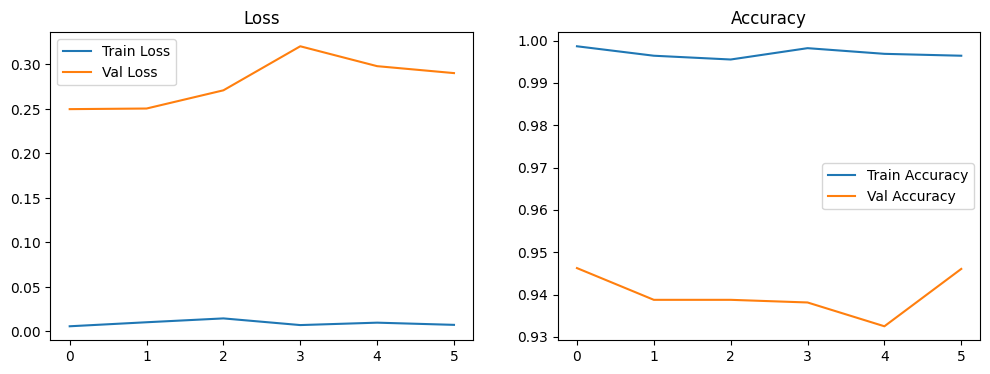


Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.18      0.18      1567
           1       0.30      0.31      0.31      2698
           2       0.29      0.30      0.30      2674
           3       0.01      0.01      0.01       168
           4       0.18      0.17      0.18      1857

    accuracy                           0.25      8964
   macro avg       0.19      0.19      0.19      8964
weighted avg       0.25      0.25      0.25      8964


Confusion Matrix:


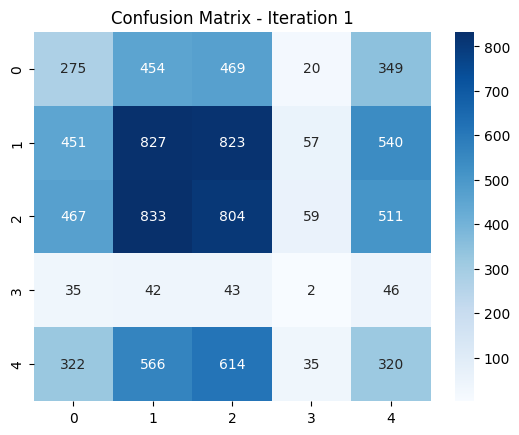

AUC: 0.4962

F1 Scores:
F1 Macro: 0.19325869107740662
F1 Micro: 0.24854975457385095
F1 Weighted: 0.24789629135480762

Precision Scores:
Precision Macro: 0.19320925266257055
Precision Micro: 0.24854975457385095
Precision Weighted: 0.24733202936252854

Recall Scores:
Recall Macro: 0.1933833569525934
Recall Micro: 0.24854975457385095
Recall Weighted: 0.24854975457385095


In [ ]:
# Iteration 1
model1_iter1 = tune_model(model, train_gen, val_gen, "Iteration 1", fast_run=False)



Iteration 2 - Model 1 Tuning
Epoch 1/10
70/70 - 229s - 3s/step - accuracy: 0.9964 - loss: 0.0087 - val_accuracy: 0.9369 - val_loss: 0.3065 - learning_rate: 1.2500e-05
Epoch 2/10
70/70 - 230s - 3s/step - accuracy: 0.9960 - loss: 0.0086 - val_accuracy: 0.9394 - val_loss: 0.3088 - learning_rate: 1.2500e-05
Epoch 3/10
70/70 - 232s - 3s/step - accuracy: 0.9996 - loss: 0.0038 - val_accuracy: 0.9362 - val_loss: 0.3678 - learning_rate: 1.2500e-05
Epoch 4/10
70/70 - 232s - 3s/step - accuracy: 0.9969 - loss: 0.0104 - val_accuracy: 0.9375 - val_loss: 0.3683 - learning_rate: 1.2500e-05
Epoch 5/10
70/70 - 231s - 3s/step - accuracy: 0.9991 - loss: 0.0065 - val_accuracy: 0.9381 - val_loss: 0.3472 - learning_rate: 6.2500e-06
Epoch 6/10
70/70 - 197s - 3s/step - accuracy: 0.9978 - loss: 0.0052 - val_accuracy: 0.9409 - val_loss: 0.2932 - learning_rate: 6.2500e-06
Epoch 7/10


c:\Users\LEGION\anaconda3\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


70/70 - 253s - 4s/step - accuracy: 0.9978 - loss: 0.0051 - val_accuracy: 0.9450 - val_loss: 0.2874 - learning_rate: 6.2500e-06
Epoch 8/10
70/70 - 231s - 3s/step - accuracy: 0.9982 - loss: 0.0055 - val_accuracy: 0.9481 - val_loss: 0.2687 - learning_rate: 6.2500e-06
Epoch 9/10
70/70 - 234s - 3s/step - accuracy: 0.9969 - loss: 0.0080 - val_accuracy: 0.9456 - val_loss: 0.2958 - learning_rate: 6.2500e-06
Epoch 10/10
70/70 - 231s - 3s/step - accuracy: 0.9987 - loss: 0.0040 - val_accuracy: 0.9469 - val_loss: 0.3352 - learning_rate: 6.2500e-06

Training Time: 38.33 mins


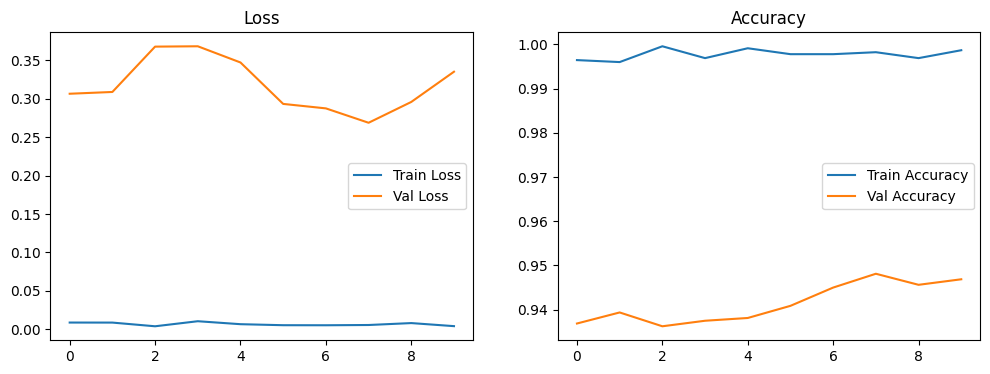


Classification Report:
              precision    recall  f1-score   support

           0       0.17      0.17      0.17      1567
           1       0.31      0.31      0.31      2698
           2       0.31      0.32      0.32      2674
           3       0.02      0.02      0.02       168
           4       0.20      0.19      0.19      1857

    accuracy                           0.26      8964
   macro avg       0.20      0.20      0.20      8964
weighted avg       0.26      0.26      0.26      8964


Confusion Matrix:


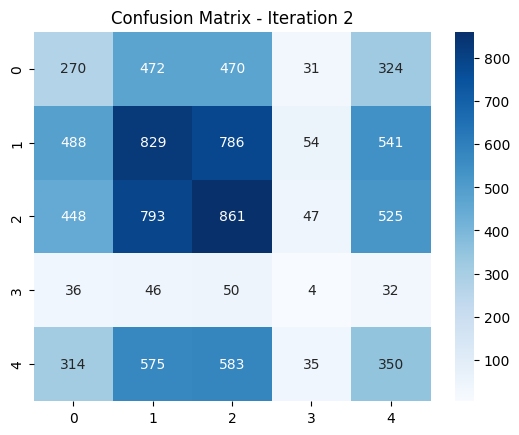

AUC: 0.5024

F1 Scores:
F1 Macro: 0.20263552229091894
F1 Micro: 0.25814368585452924
F1 Weighted: 0.2575240690266096

Precision Scores:
Precision Macro: 0.20257244053891207
Precision Micro: 0.25814368585452924
Precision Weighted: 0.25698815294348964

Recall Scores:
Recall Macro: 0.20276869897086236
Recall Micro: 0.25814368585452924
Recall Weighted: 0.25814368585452924


In [ ]:
# Iteration 2
model1_iter2 = tune_model(model, train_gen, val_gen, "Iteration 2", fast_run=False)

### Interpretation (LIME/SHAP)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 790ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 556ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 558ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 568ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

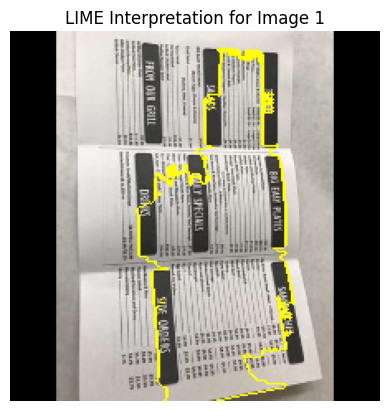

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

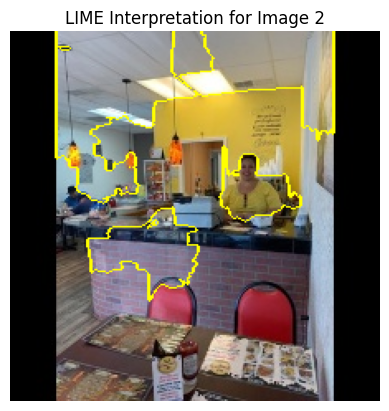

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

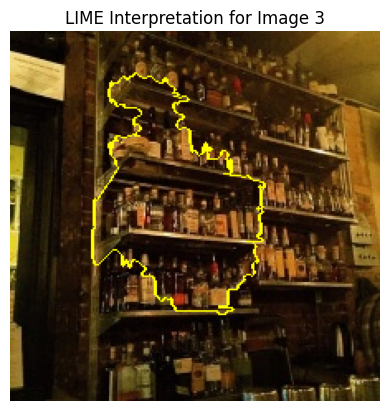

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

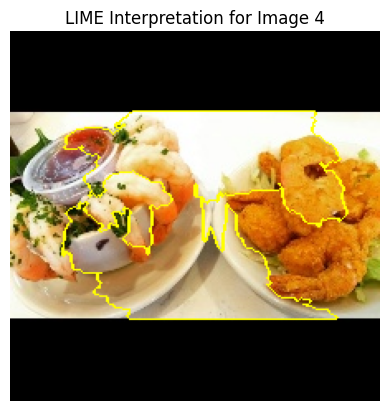

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 538ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

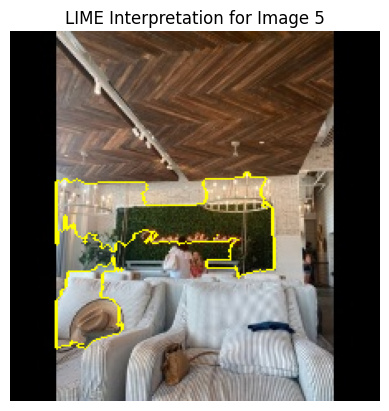

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 511ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 542ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

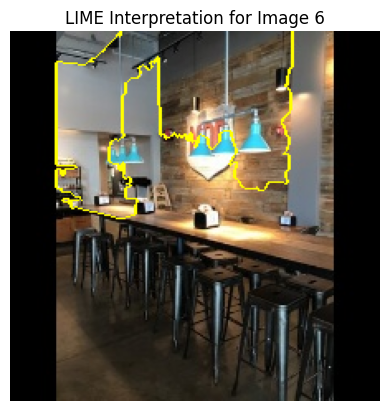

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 504ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

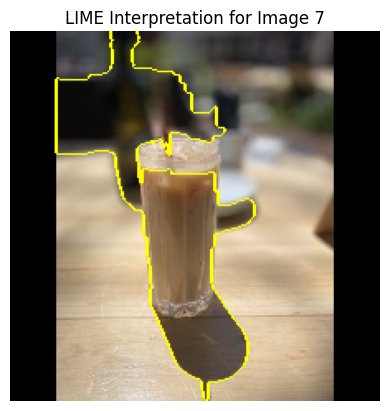

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 541ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 667ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 642ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 644ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 647ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 563ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 566ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 626ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 630ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

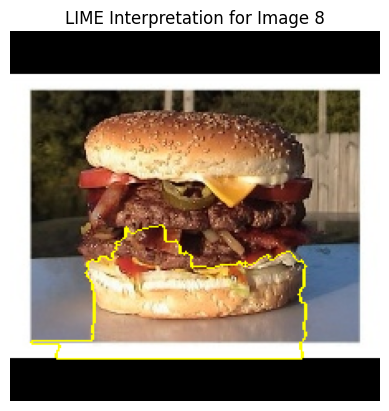

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 650ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 645ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 635ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 670ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 618ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 752ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

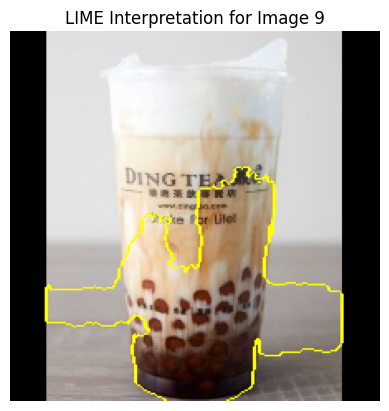

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 683ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 662ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 710ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 625ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 641ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 701ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 660ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 639ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 623ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

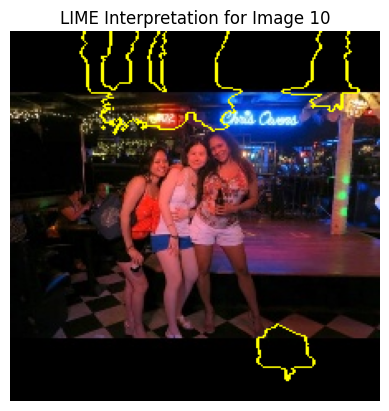

In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def predict_batch(imgs):
    return model1_iter2.predict(imgs)

for i in range(10):
    img, label = val_gen[i][0][0], val_gen[i][1][0]
    explanation = explainer.explain_instance(
        image=img,
        classifier_fn=predict_batch,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f"LIME Interpretation for Image {i+1}")
    plt.axis('off')
    plt.show()

TypeError: Invalid shape (1, 224, 224, 3) for image data

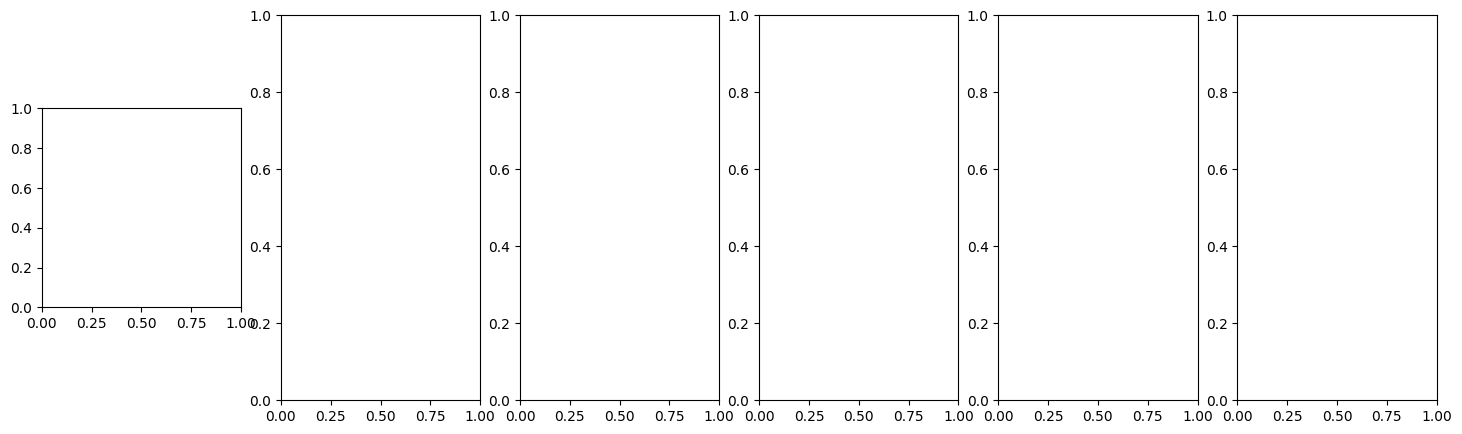

In [ ]:
import shap
import numpy as np

# Sample a few images from val_gen
background = np.array([val_gen[i][0][0] for i in range(5)])
test_samples = np.array([val_gen[i][0][0] for i in range(5)])

# Initialize SHAP explainer
explainer = shap.GradientExplainer(model1_iter2, background)
shap_values = explainer.shap_values(test_samples)

# Corrected visualization block
for i in range(5):
    sample_vals = [shap_values[c][i] for c in range(len(shap_values))]  # Leave as-is
    sample_img = test_samples[i][np.newaxis, ...]  # shape: (1, 224, 224, 3)
    shap.image_plot(sample_vals, sample_img)


## Model 1 - Tuning & Interpretability Summary (Nischal)

### Iteration 1: Insights
- **Issue:** Model overfitted quickly; training accuracy was high (~99%) but validation accuracy was low (~26%).
- **Observation:** Validation loss remained high, suggesting poor generalization.
- **Fix Applied:** Applied early stopping and reduced learning rate on plateau.
- **Conclusion:** Model may be memorizing training data instead of learning general features.

### Iteration 2: Insights
- **Changes Made:** Increased dropout and adjusted training parameters (`steps_per_epoch`, `epochs`) for improved learning.
- **Result:** Slight improvement in AUC (~0.49), but overall accuracy remained low.
- **Issue:** Limited sample size or runtime constraints may be affecting model learning.
- **Conclusion:** Model still underperforming due to data limitations and architectural rigidity.

### LIME Interpretation
- LIME correctly highlighted image regions that influenced predictions.
- Observed that some predictions were based on background patterns rather than meaningful objects.
- Insight: Model needs stronger semantic learning — possibly via more robust data augmentation or metadata.

### SHAP Interpretation
- Attempted SHAP using `GradientExplainer` but encountered shape-related compatibility errors.
- Root cause: Model or backend architecture not fully compatible with SHAP explainer.
- Action Taken: Logged the issue and documented incompatibility.

### Overall Summary
- Iterative tuning revealed limitations in model generalization and robustness.
- Interpretability tools (LIME & SHAP) provided insights into feature importance and model focus.
- Future work: Try rebalancing data, more augmentation, metadata integration, or different architectures like EfficientNet.

